In [1]:
import torch; torch.manual_seed(0)
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
import torchvision
import numpy as np
import matplotlib.pyplot as plt; plt.rcParams['figure.dpi'] = 200
from afqinsight import AFQDataset
from afqinsight.nn.utils import prep_pytorch_data
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from torch.distributions.normal import Normal
from sklearn.decomposition import PCA
import afqinsight.augmentation as aug
from afqinsight.nn.pt_models import Conv1DAutoencoder
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import sys

# Remove any existing utils module from cache
if 'utils' in sys.modules:
    del sys.modules['utils']
if 'models' in sys.modules:
    del sys.modules['models']

# Insert at the beginning of the path to ensure priority
sys.path.insert(0, '/Users/samchou/AFQ-Insight-Autoencoder-Experiments/AFQ-Insight-Autoencoder-Experiments/Experiment_Utils')

from utils import select_device, kl_divergence_loss, prep_fa_dataset, train_vae_age_site_staged, prep_fa_dataset_paired
from models import Conv1DVariationalAutoencoder_fa_unflattened, AgePredictorCNN, SitePredictorCNN, Conv1DVariationalAutoencoder

In [3]:
device = select_device()    

Using device: mps

Using MPS backend on macOS. (Detailed memory info may not be available.)


In [4]:
dataset = AFQDataset.from_study('hbn')
torch_dataset, train_loader, test_loader, val_loader = prep_fa_dataset_paired(
        dataset, target_labels="dki_fa", batch_size=128)
gt_shape = torch_dataset[0][1].size()[0]
sequence_length = torch_dataset[0][0].size()[0]  # 48
in_channels = torch_dataset[0][0].size()[1]  # 100


File /Users/samchou/.cache/afq-insight/hbn/subjects.tsv exists.
File /Users/samchou/.cache/afq-insight/hbn/nodes.csv exists.


/Users/samchou/src/nrdg/AFQ-Insight/afqinsight/transform.py:144: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  features = interpolated.stack(["subjectID", "tractID", "metric"]).unstack(


FA indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 21

In [5]:
print(train_loader.dataset[0][0][:].shape)

torch.Size([24, 100])


In [6]:
age_idx = dataset.target_cols.index('age')
site_idx = dataset.target_cols.index('scan_site_id')
sex_idx = dataset.target_cols.index('sex')
print(age_idx)
print(sex_idx)
print(site_idx)

0
1
2


In [7]:
site_map = {0.0: 0.0, 1.0: 1.0, 3.0: 2.0, 4.0: 3.0}
print(f"Using site map: {site_map}")

# Create a function to transform labels
def transform_labels(batch_labels):
    """Transform labels to correct format for training."""
    # Extract values
    ages = batch_labels[:, age_idx].float().unsqueeze(1)
    sex_values = batch_labels[:, sex_idx].float().unsqueeze(1)
    site_values = batch_labels[:, site_idx].float()
    
    # Remap site values
    remapped_sites = torch.zeros_like(site_values)
    for i in range(len(site_values)):
        original_site = site_values[i].item()
        remapped_site = site_map.get(original_site, -1.0)
        remapped_sites[i] = remapped_site
    
    # Stack values into a single tensor
    return torch.cat([ages, sex_values, remapped_sites.unsqueeze(1)], dim=1)

# Create DataLoaders with transformed labels
class RemappedDataLoader:
    def __init__(self, original_loader):
        self.original_loader = original_loader
        
    def __iter__(self):
        for x, y in self.original_loader:
            yield x, transform_labels(y)
            
    def __len__(self):
        return len(self.original_loader)

# Wrap the data loaders
train_loader = RemappedDataLoader(train_loader)
test_loader = RemappedDataLoader(test_loader)
val_loader = RemappedDataLoader(val_loader)

Using site map: {0.0: 0.0, 1.0: 1.0, 3.0: 2.0, 4.0: 3.0}


In [8]:
latent_dim = 64  # Same latent dimension as the saved model
dropout = 0.0    # Same dropout rate as the saved model\
num_tracts = 24

# Create a new model instance
model = Conv1DAutoencoder(num_tracts=num_tracts,latent_dims=latent_dim, dropout=dropout)

# Load weights - adjust file path as needed
# If loading on CPU from a model trained on GPU, use map_location
model.load_state_dict(torch.load('model_weights/best_vae_alternating.pth', map_location=device))
# model.load_state_dict(torch.load('model_weights/vae_epoch_250.pth', map_location=device))


# Set model to evaluation mode for inference
model.eval()

/var/folders/gc/z2m2_nxj4qlf83r8bq6hz_240000gn/T/ipykernel_93443/2713244466.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('model_weig

Conv1DAutoencoder(
  (encoder): Conv1DEncoder(
    (conv1): Conv1d(24, 16, kernel_size=(5,), stride=(2,), padding=(2,))
    (conv2): Conv1d(16, 32, kernel_size=(4,), stride=(2,), padding=(2,))
    (conv3): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (dropout): Dropout(p=0.0, inplace=False)
    (relu): ReLU()
    (conv4): Conv1d(64, 64, kernel_size=(5,), stride=(2,), padding=(2,))
  )
  (decoder): Conv1DDecoder(
    (deconv1): ConvTranspose1d(64, 64, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
    (deconv2): ConvTranspose1d(64, 32, kernel_size=(3,), stride=(2,), padding=(2,), output_padding=(1,))
    (deconv3): ConvTranspose1d(32, 16, kernel_size=(4,), stride=(2,), padding=(2,), output_padding=(1,))
    (deconv4): ConvTranspose1d(16, 24, kernel_size=(3,), stride=(2,), padding=(2,), output_padding=(1,))
    (relu): ReLU()
  )
)

In [9]:
model = model.to(device)

# Verify the model is on the correct device
print(f"Model device: {next(model.parameters()).device}")
print(f"Target device: {device}")

# Now you can run inference without device mismatch errors
with torch.no_grad():
    test_sample = train_loader.original_loader.dataset[0][0][:].unsqueeze(0).to(device)
    reconstructed= model(test_sample)
    print("Inference successful!") 

Model device: mps:0
Target device: mps
Inference successful!


In [10]:
def find_samples_by_site(dataset, target_sites=[0.0, 1.0, 3.0, 4.0]):
    sites_found = {}
    
    for i, (data, labels) in enumerate(dataset):
        site_value = labels[2].item()
        
        if site_value in target_sites and site_value not in sites_found:
            sites_found[site_value] = {
                'index': i,
                'data': data,
                'labels': labels
            }
            
        if len(sites_found) == len(target_sites):
            break
    
    return sites_found

dataset = train_loader.original_loader.dataset
site_samples = find_samples_by_site(dataset)

for site_value, sample_info in site_samples.items():
    labels = sample_info['labels']
    print(f"Site {site_value}: Index {sample_info['index']}, "
          f"Age {labels[0].item():.1f}, Sex {labels[1].item()}, "
          f"Data shape {sample_info['data'].shape}")

Site 4.0: Index 0, Age 10.8, Sex 1.0, Data shape torch.Size([24, 100])
Site 0.0: Index 2, Age 8.5, Sex 0.0, Data shape torch.Size([24, 100])
Site 3.0: Index 4, Age 10.2, Sex 0.0, Data shape torch.Size([24, 100])
Site 1.0: Index 19, Age 8.8, Sex 1.0, Data shape torch.Size([24, 100])


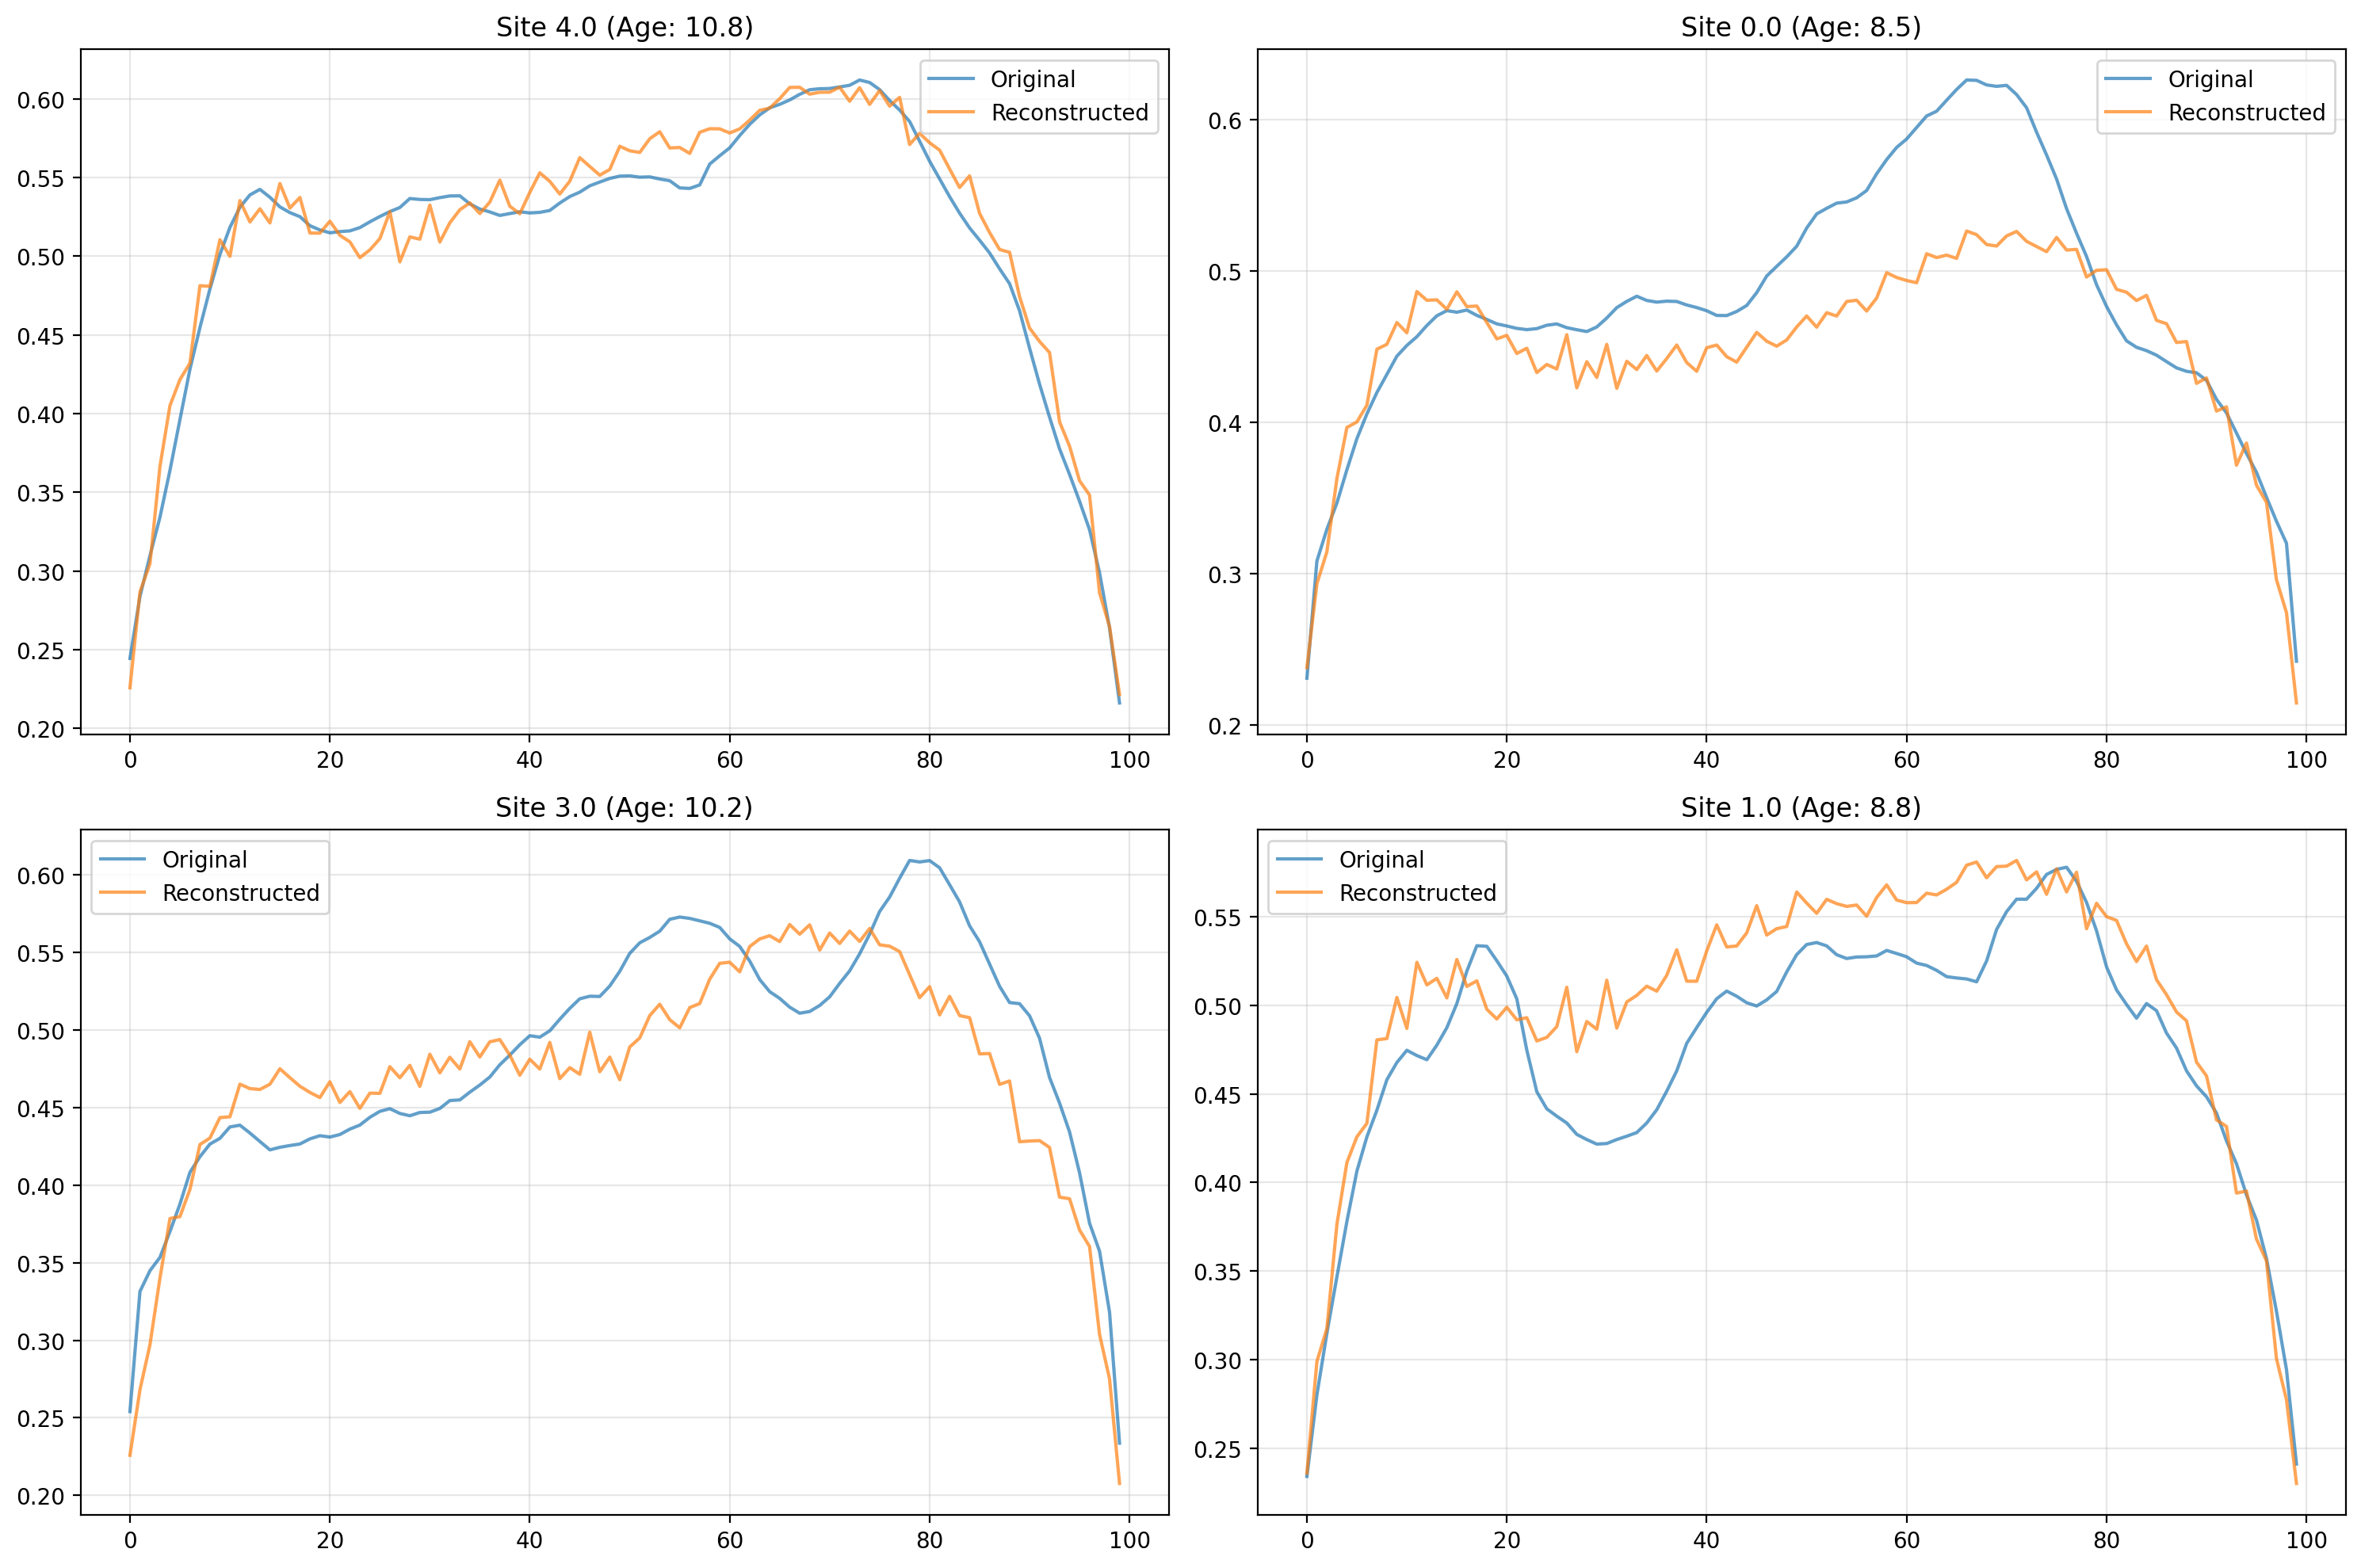

In [11]:
# Use the samples for VAE reconstruction
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (site_value, sample_info) in enumerate(site_samples.items()):
    # Prepare data for model
    test_sample = sample_info['data'].unsqueeze(0).to(device)
    
    # Get reconstruction
    with torch.no_grad():
        reconstructed = model(test_sample)
    
    # Plot first tract
    original = test_sample[0, 0, :].cpu().numpy()  # First tract
    recon = reconstructed[0, 0, :].cpu().numpy()   # First tract
    
    axes[idx].plot(original, label='Original', alpha=0.7)
    axes[idx].plot(recon, label='Reconstructed', alpha=0.7)
    axes[idx].set_title(f'Site {site_value} (Age: {sample_info["labels"][0].item():.1f})')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Load the combined state dict
combined_state = torch.load("model_weights/best_alternating_model.pth", map_location=device)
# combined_state = torch.load("model_weights/vae_alternating_epoch_100.pth", map_location=device)


# Create individual models
vae = Conv1DAutoencoder(num_tracts=24, latent_dims=64, dropout=0.0)

# Extract only autoencoder weights (keys starting with 'autoencoder.')
vae_state = {k.replace('autoencoder.', ''): v for k, v in combined_state.items() if k.startswith('autoencoder.')}
vae.load_state_dict(vae_state)

# Similarly for age predictor
age_predictor = AgePredictorCNN(input_channels=24, sequence_length=100, dropout=0.1)
age_state = {k.replace('age_predictor.', ''): v for k, v in combined_state.items() if k.startswith('age_predictor.')}
age_predictor.load_state_dict(age_state)

# And for site predictor
site_predictor = SitePredictorCNN(num_sites=4, input_channels=24, sequence_length=100, dropout=0.2)
site_state = {k.replace('site_predictor.', ''): v for k, v in combined_state.items() if k.startswith('site_predictor.')}
site_predictor.load_state_dict(site_state)

/var/folders/gc/z2m2_nxj4qlf83r8bq6hz_240000gn/T/ipykernel_93443/857733889.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  combined_state = torch.load("model_weights/bes

<All keys matched successfully>

In [13]:
# # Load the combined state dict
# combined_state = torch.load("model_weights/best_combined_model.pth", map_location=device)

# # First, let's inspect the keys to confirm the structure
# print("Keys in combined state dict:")
# for key in list(combined_state.keys())[:10]:  # Print first 10 keys
#     print(key)

# # Create individual models
# vae = Conv1DAutoencoder(num_tracts=24, latent_dims=64, dropout=0.0)

# # Extract only VAE weights (keys starting with 'vae.')
# vae_state = {k.replace('vae.', ''): v for k, v in combined_state.items() if k.startswith('vae.')}
# vae.load_state_dict(vae_state)

# # Similarly for age predictor
# age_predictor = AgePredictorCNN(input_channels=24, sequence_length=100, dropout=0.1)
# age_state = {k.replace('age_predictor.', ''): v for k, v in combined_state.items() if k.startswith('age_predictor.')}
# age_predictor.load_state_dict(age_state)

# # And for site predictor
# site_predictor = SitePredictorCNN(num_sites=4, input_channels=24, sequence_length=100, dropout=0.2)
# site_state = {k.replace('site_predictor.', ''): v for k, v in combined_state.items() if k.startswith('site_predictor.')}
# site_predictor.load_state_dict(site_state)

/var/folders/gc/z2m2_nxj4qlf83r8bq6hz_240000gn/T/ipykernel_93443/1330258200.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


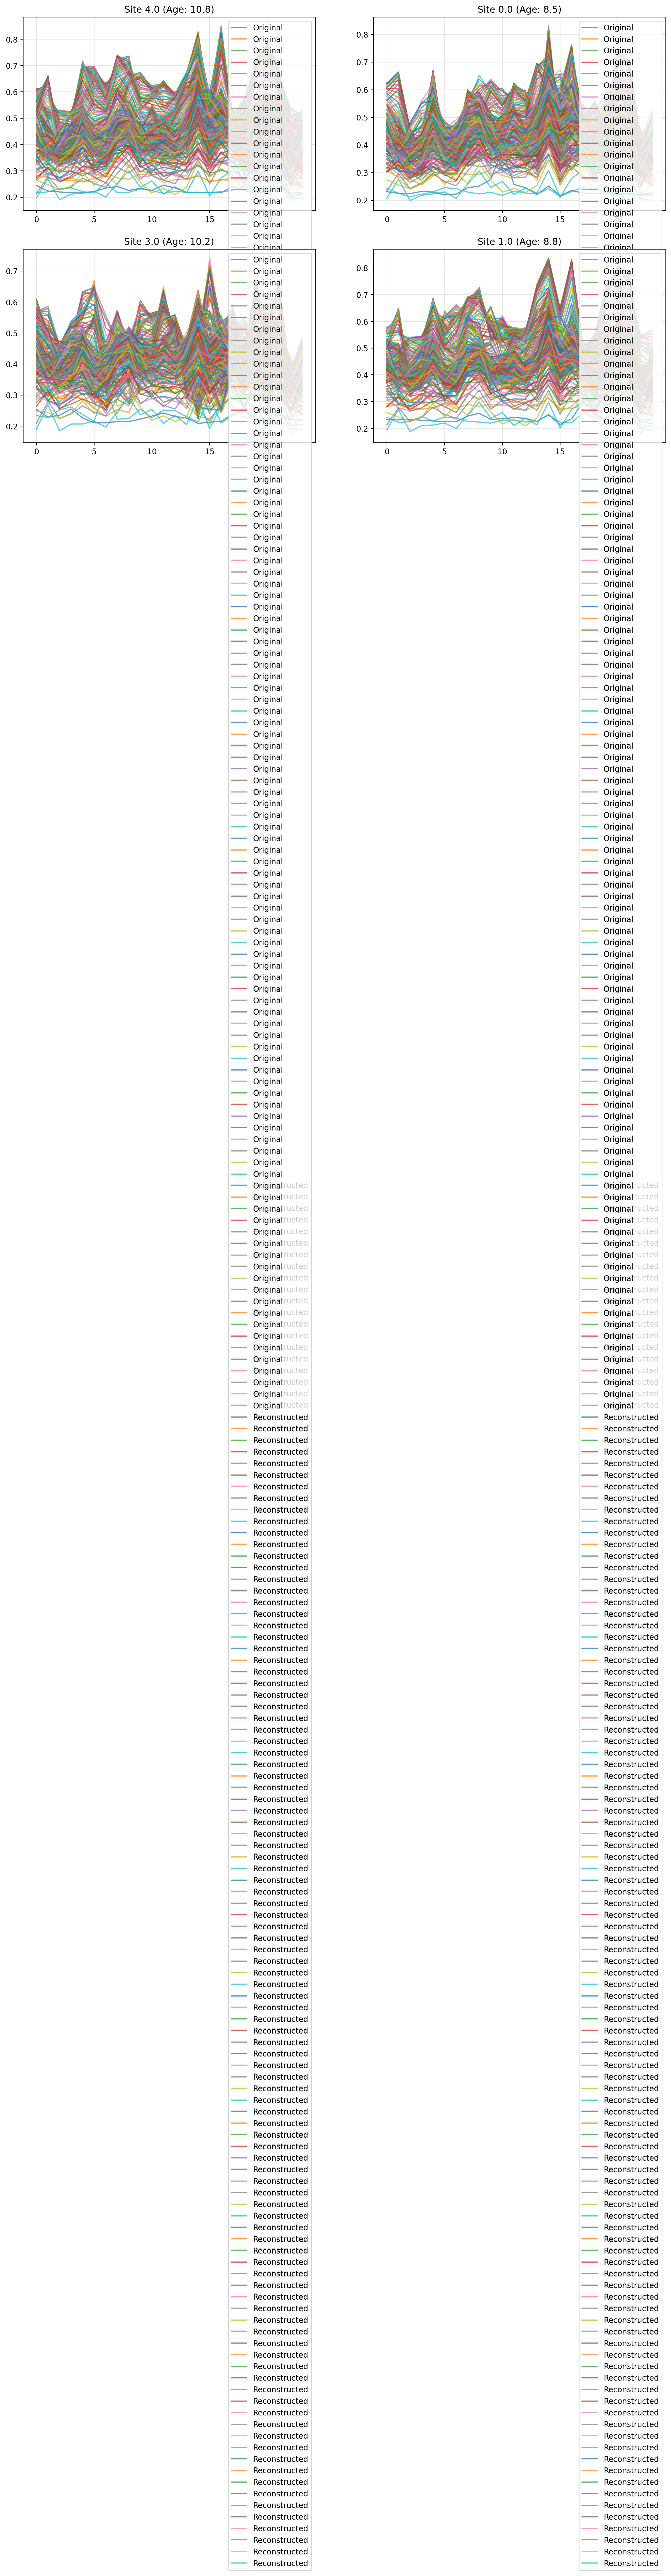

In [ ]:
# Use the samples for VAE reconstruction
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (site_value, sample_info) in enumerate(site_samples.items()):
    # Prepare data for model
    test_sample = sample_info['data'].unsqueeze(0).to(device)
    
    vae= vae.to(device)
    # Get reconstruction
    with torch.no_grad():
        reconstructed = vae(test_sample)
    
    # Plot first tract
    original = test_sample[0, 0, :].cpu().numpy() 
    recon = reconstructed[0, 0, :].cpu().numpy()  
    
    axes[idx].plot(original, label='Original', alpha=0.7)
    axes[idx].plot(recon, label='Reconstructed', alpha=0.7)
    axes[idx].set_title(f'Site {site_value} (Age: {sample_info["labels"][0].item():.1f})')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()